# Lorenz-63 discretizer benchmark: D-EnKF vs CD-EnKF

This **deep dive** compares the continuous-time Lorenz-63 SDE under two filtering framings:

- **D-EnKF:** first approximate the SDE transition law with `Discretizer(discretize=...)`, then run the ordinary discrete-time `EnKFConfig`.
- **CD-EnKF:** run `ContinuousTimeEnKFConfig`, which delegates continuous-discrete EnKF propagation to `cd_dynamax`.

The goal is not to estimate parameters. We fix the Lorenz parameter at the data-generating value, generate one synthetic data set with a fine Euler-Maruyama simulator, and then compare approximate marginal likelihoods at a moderate observation gap. The reported metrics are the negative marginal log-likelihood (NLL; lower is better) and wall-clock time after one warm-up call, so compilation/JIT time is excluded from the benchmark loop.

We compare:

- `euler_maruyama`
- `frozen_jacobian_gaussian`
- `taylor_moment_gaussian`
- `simulated_likelihood`
- `ContinuousTimeEnKFConfig` with `filter_source="cd_dynamax"` as the direct continuous-time baseline

Because EnKF is stochastic, the filters use fixed common random numbers. Absolute timings depend on hardware and JAX configuration; the relative pattern is usually the useful part.

**Step-size note:** Lorenz-63 is a sharp stress test for one-step SDE approximations. The default `OBS_DT = 0.05` is coarse enough for discretization error to matter, but small enough that the second-order Taylor moment transition remains inside its useful step-size regime. At `OBS_DT = 0.1`, the raw Taylor moment Gaussian often becomes numerically unstable over this horizon; that is an important limitation of this weak expansion, not a JAX timing artifact.

## Imports and config

In [1]:
import os
import time

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from IPython.display import Markdown, display
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    Discretizer,
    DynamicalModel,
    Filter,
    LinearGaussianObservation,
    SDESimulator,
    euler_maruyama,
    frozen_jacobian_gaussian,
    simulated_likelihood,
    taylor_moment_gaussian,
)
from dynestyx.inference.filters import ContinuousTimeEnKFConfig, EnKFConfig

In [2]:
SMOKE = os.environ.get("DYNESTYX_NOTEBOOK_SMOKE") == "1"

TRUE_RHO = 28.0
STATE_DIM = 3
OBS_DIM = 1

# The default gap is deliberately coarse enough for discretization error to matter,
# while keeping the Taylor moment expansion in its stable regime on L63.
OBS_DT = 5e-2
T_FINAL = 2.0

# Data are generated with a finer simulator than the benchmark filters use.
DATA_DT = 1e-3
CD_DYNAMAX_DT0 = 1e-2

N_ENKF_PARTICLES = 25
N_REPEATS = 10

SL_N_SUBSTEPS = 8
SL_N_SIMULATIONS = 32

PROCESS_NOISE_SCALE = 0.8
OBS_NOISE_SCALE = 1.0

DATA_SEED = 0
ENKF_SEED = 101
SL_SEED = 202
EVAL_SEED = 303

obs_times = jnp.arange(0.0, T_FINAL + 0.5 * OBS_DT, OBS_DT)

print(f"Smoke mode: {SMOKE}")
print(f"Observation count: {len(obs_times)}")
print(f"Observation gap: {OBS_DT}")
print(f"EnKF particles: {N_ENKF_PARTICLES}")

Smoke mode: False
Observation count: 41
Observation gap: 0.05
EnKF particles: 25


## Lorenz-63 SDE

The latent process is the stochastic Lorenz-63 system

$$
dx = f(x)\,dt + \sigma_{\text{diff}}\,dW,
\qquad
f(x) = \begin{pmatrix}
\sigma(x_2 - x_1) \\
x_1(\rho - x_3) - x_2 \\
x_1x_2 - \beta x_3
\end{pmatrix}.
$$

We fix $\sigma=10$, $\beta=8/3$, $\rho=28$, and $\sigma_{\text{diff}}=0.8$. Only the first coordinate is observed with Gaussian noise: $y_t = Hx(t) + \varepsilon_t = x_1(t) + \varepsilon_t$, $\varepsilon_t \sim \mathcal{N}(0, \sigma_{\text{obs}}^2)$ with $\sigma_{\text{obs}}=1$. We keep $\rho$ as a NumPyro sample site so the same model could be used in inference, but in this benchmark it is fixed to the true value through `Predictive(params={"rho": ...})`.

In [3]:
def lorenz63_model(obs_times=None, obs_values=None, predict_times=None):
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0))

    def drift(x, u, t):
        del u, t
        return jnp.array(
            [
                10.0 * (x[1] - x[0]),
                x[0] * (rho - x[2]) - x[1],
                x[0] * x[1] - (8.0 / 3.0) * x[2],
            ]
        )

    def diffusion_coefficient(x, u, t):
        del x, u, t
        return PROCESS_NOISE_SCALE * jnp.eye(STATE_DIM)

    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.array([1.0, 1.0, 20.0]),
            covariance_matrix=0.5**2 * jnp.eye(STATE_DIM),
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=drift,
            diffusion_coefficient=diffusion_coefficient,
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.array([[1.0, 0.0, 0.0]]),
            R=OBS_NOISE_SCALE**2 * jnp.eye(OBS_DIM),
        ),
    )

    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )

## Generate one synthetic data set

The observations are generated once with `SDESimulator(source="em_scan")` using a much smaller internal step than the observation gap. This avoids giving any one benchmark discretizer the advantage of also being the data-generating transition at the observation grid.

Observations: (41, 1)
States: (41, 3)


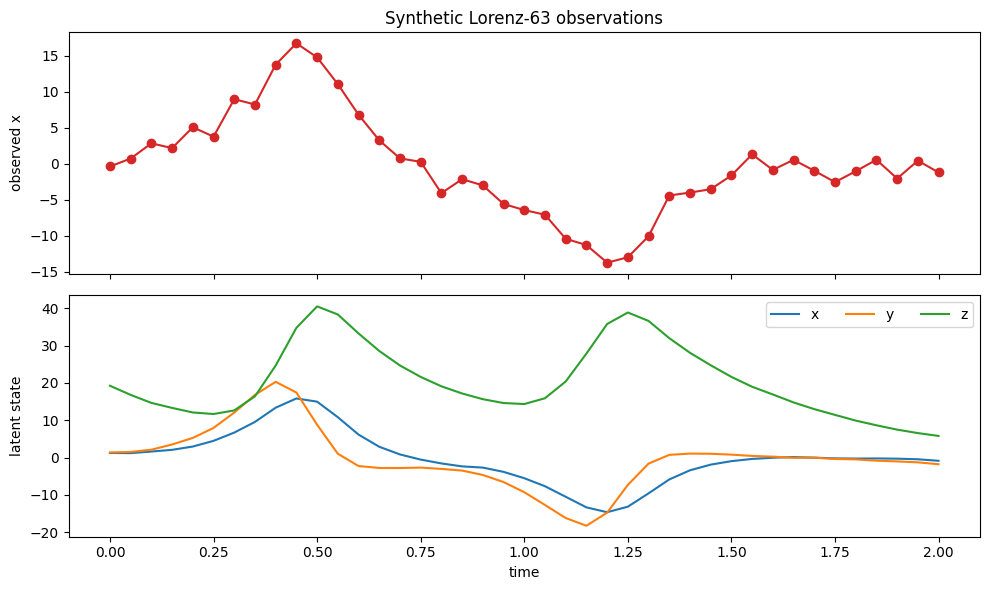

In [4]:
predictive_data = Predictive(
    lorenz63_model,
    params={"rho": jnp.array(TRUE_RHO)},
    num_samples=1,
    exclude_deterministic=False,
)

with SDESimulator(source="em_scan", dt0=DATA_DT):
    synthetic = predictive_data(jr.PRNGKey(DATA_SEED), predict_times=obs_times)


def squeeze_time_series(x):
    x = jnp.asarray(x)
    while x.ndim > 2:
        x = x[0]
    return x


obs_values = squeeze_time_series(synthetic["f_observations"])
states = squeeze_time_series(synthetic["f_states"])

print("Observations:", obs_values.shape)
print("States:", states.shape)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(np.asarray(obs_times), np.asarray(obs_values[:, 0]), "o-", color="C3")
axes[0].set_ylabel("observed x")
axes[0].set_title("Synthetic Lorenz-63 observations")

for idx, label in enumerate(["x", "y", "z"]):
    axes[1].plot(np.asarray(obs_times), np.asarray(states[:, idx]), label=label)
axes[1].set_xlabel("time")
axes[1].set_ylabel("latent state")
axes[1].legend(ncol=3)
plt.tight_layout()
plt.show()

## Benchmark helpers

For the discretized methods, `Discretizer` turns the continuous-time state evolution into a discrete-time transition over each observation interval, and the ordinary cuthbert-backed `EnKFConfig` filters that approximate discrete model. For the continuous baseline, `ContinuousTimeEnKFConfig` filters the original SDE directly through `cd_dynamax`.

Each method is warmed once and blocked before timing. The timed loop then reuses the same runner, data, parameter value, and common random numbers.

In [5]:
def make_discrete_enkf_config():
    return EnKFConfig(
        n_particles=N_ENKF_PARTICLES,
        crn_seed=jr.PRNGKey(ENKF_SEED),
        perturb_measurements=True,
        inflation_delta=0.0,
        warn=False,
    )


def make_continuous_enkf_config():
    return ContinuousTimeEnKFConfig(
        n_particles=N_ENKF_PARTICLES,
        crn_seed=jr.PRNGKey(ENKF_SEED),
        perturb_measurements=True,
        inflation_delta=0.0,
        diffeqsolve_dt0=CD_DYNAMAX_DT0,
        diffeqsolve_max_steps=2_000,
        warn=False,
    )


METHODS = [
    {
        "name": "CD-EnKF (cd_dynamax continuous)",
        "kind": "continuous",
        "discretize": None,
    },
    {
        "name": "D-EnKF + Euler-Maruyama",
        "kind": "discrete",
        "discretize": euler_maruyama,
    },
    {
        "name": "D-EnKF + frozen Jacobian Gaussian",
        "kind": "discrete",
        "discretize": frozen_jacobian_gaussian,
    },
    {
        "name": "D-EnKF + Taylor moment Gaussian",
        "kind": "discrete",
        "discretize": taylor_moment_gaussian,
    },
    {
        "name": "D-EnKF + simulated likelihood",
        "kind": "discrete",
        "discretize": lambda cte: simulated_likelihood(
            cte,
            n_substeps=SL_N_SUBSTEPS,
            n_simulations=SL_N_SIMULATIONS,
            seed=SL_SEED,
        ),
    },
]


def make_conditioned_model(method):
    config = (
        make_continuous_enkf_config()
        if method["kind"] == "continuous"
        else make_discrete_enkf_config()
    )

    def model():
        with Filter(filter_config=config):
            if method["kind"] == "continuous":
                return lorenz63_model(obs_times=obs_times, obs_values=obs_values)
            with Discretizer(discretize=method["discretize"]):
                return lorenz63_model(obs_times=obs_times, obs_values=obs_values)

    return model


def make_runner(method):
    model = make_conditioned_model(method)
    predictive = Predictive(
        model,
        params={"rho": jnp.array(TRUE_RHO)},
        num_samples=1,
        exclude_deterministic=False,
    )

    def run_once():
        out = predictive(jr.PRNGKey(EVAL_SEED))
        return out["f_marginal_loglik"].squeeze()

    return run_once


def block_scalar(x):
    x = jnp.asarray(x)
    x.block_until_ready()
    return float(x)

## Run the benchmark

The table reports NLL at the fixed true parameter value, plus the median and minimum elapsed time across post-warm-up repeats. The `Speedup vs CD-EnKF` column uses median times.

In [6]:
def benchmark_method(method):
    runner = make_runner(method)

    warmup_loglik = block_scalar(runner())
    timings = []
    logliks = []
    status = "ok" if np.isfinite(warmup_loglik) else "non-finite warm-up"

    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        loglik = block_scalar(runner())
        timings.append(time.perf_counter() - t0)
        logliks.append(loglik)
        if not np.isfinite(loglik):
            status = "non-finite timed run"

    finite_logliks = np.asarray([value for value in logliks if np.isfinite(value)])
    mean_loglik = float(np.mean(finite_logliks)) if len(finite_logliks) else np.nan
    return {
        "method": method["name"],
        "status": status,
        "nll": -mean_loglik if np.isfinite(mean_loglik) else np.inf,
        "nll_samples": [-value for value in logliks if np.isfinite(value)],
        "loglik_std": float(np.std(finite_logliks)) if len(finite_logliks) else np.nan,
        "median_time_s": float(np.median(timings)),
        "min_time_s": float(np.min(timings)),
        "timings_s": timings,
        "warmup_loglik": warmup_loglik,
    }


results = []
for method in METHODS:
    print(f"Running {method['name']}...")
    result = benchmark_method(method)
    results.append(result)
    print(
        f"  status={result['status']}, "
        f"NLL={result['nll']:.3f}, "
        f"median={result['median_time_s']:.4f}s, "
        f"min={result['min_time_s']:.4f}s"
    )

Running CD-EnKF (cd_dynamax continuous)...
  status=ok, NLL=76.661, median=0.6166s, min=0.5886s
Running D-EnKF + Euler-Maruyama...
  status=ok, NLL=318.174, median=0.3119s, min=0.3039s
Running D-EnKF + frozen Jacobian Gaussian...
  status=ok, NLL=76.523, median=0.6419s, min=0.5129s
Running D-EnKF + Taylor moment Gaussian...
  status=ok, NLL=83.383, median=0.6265s, min=0.5393s
Running D-EnKF + simulated likelihood...
  status=ok, NLL=82.304, median=0.6515s, min=0.6156s


| Method | Status | NLL | Delta NLL | Median time (s) | Min time (s) | Speedup vs CD-EnKF |
|---|---|---:|---:|---:|---:|---:|
| CD-EnKF (cd_dynamax continuous) | ok | 76.661 | 0.138 | 0.6166 | 0.5886 | 1.00x |
| D-EnKF + Euler-Maruyama | ok | 318.174 | 241.650 | 0.3119 | 0.3039 | 1.98x |
| D-EnKF + frozen Jacobian Gaussian | ok | 76.523 | 0.000 | 0.6419 | 0.5129 | 0.96x |
| D-EnKF + Taylor moment Gaussian | ok | 83.383 | 6.859 | 0.6265 | 0.5393 | 0.98x |
| D-EnKF + simulated likelihood | ok | 82.304 | 5.780 | 0.6515 | 0.6156 | 0.95x |

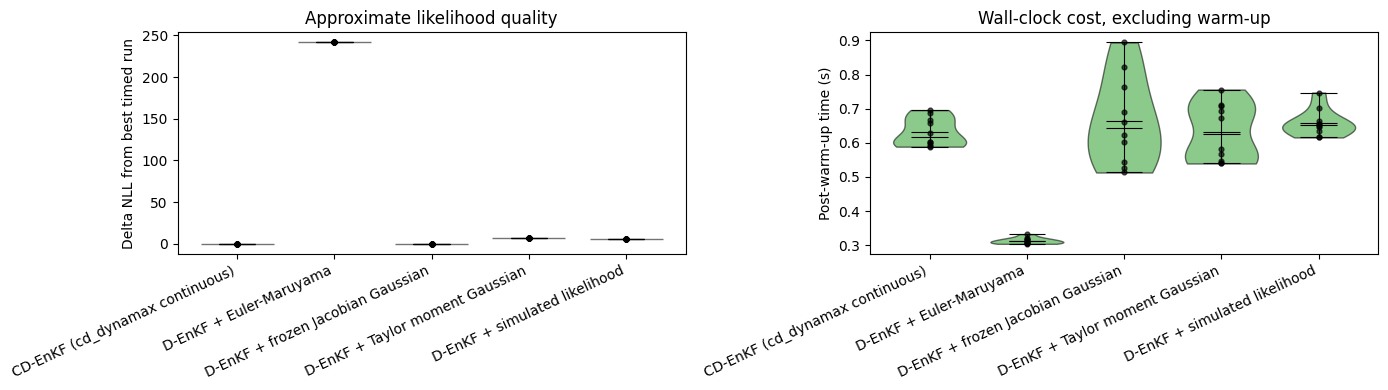

In [7]:
def results_markdown_table(results):
    cd_time = results[0]["median_time_s"]
    finite_nlls = [r["nll"] for r in results if np.isfinite(r["nll"])]
    best_nll = min(finite_nlls) if finite_nlls else np.nan

    lines = [
        "| Method | Status | NLL | Delta NLL | Median time (s) | Min time (s) | Speedup vs CD-EnKF |",
        "|---|---|---:|---:|---:|---:|---:|",
    ]
    for result in results:
        speedup = cd_time / result["median_time_s"]
        nll = result["nll"]
        delta = nll - best_nll if np.isfinite(nll) and np.isfinite(best_nll) else np.nan
        lines.append(
            "| {method} | {status} | {nll} | {delta} | {median:.4f} | {min_time:.4f} | {speedup:.2f}x |".format(
                method=result["method"],
                status=result["status"],
                nll=f"{nll:.3f}" if np.isfinite(nll) else "failed",
                delta=f"{delta:.3f}" if np.isfinite(delta) else "failed",
                median=result["median_time_s"],
                min_time=result["min_time_s"],
                speedup=speedup,
            )
        )
    return "\n".join(lines)


display(Markdown(results_markdown_table(results)))

labels = [r["method"] for r in results]
x = np.arange(len(results))
finite_nlls = [value for r in results for value in r["nll_samples"]]
best_nll = min(finite_nlls) if finite_nlls else np.nan

nll_positions = []
delta_nll_samples = []
for idx, result in enumerate(results):
    samples = np.asarray(result["nll_samples"], dtype=float)
    if samples.size:
        nll_positions.append(idx)
        delta_nll_samples.append(samples - best_nll)

time_samples = [np.asarray(r["timings_s"], dtype=float) for r in results]


def style_violin(parts, color):
    for body in parts["bodies"]:
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.55)
    for key in ("cmeans", "cmedians", "cbars", "cmins", "cmaxes"):
        if key in parts:
            parts[key].set_edgecolor("black")
            parts[key].set_linewidth(0.8)


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if delta_nll_samples:
    nll_parts = axes[0].violinplot(
        delta_nll_samples,
        positions=nll_positions,
        showmeans=True,
        showmedians=True,
        widths=0.75,
    )
    style_violin(nll_parts, "C0")
    for position, samples in zip(nll_positions, delta_nll_samples):
        axes[0].scatter(
            np.full_like(samples, position, dtype=float),
            samples,
            color="black",
            s=12,
            alpha=0.65,
            zorder=3,
        )
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=25, ha="right")
axes[0].set_ylabel("Delta NLL from best timed run")
axes[0].set_title("Approximate likelihood quality")

time_parts = axes[1].violinplot(
    time_samples,
    positions=x,
    showmeans=True,
    showmedians=True,
    widths=0.75,
)
style_violin(time_parts, "C2")
for position, samples in zip(x, time_samples):
    axes[1].scatter(
        np.full_like(samples, position, dtype=float),
        samples,
        color="black",
        s=12,
        alpha=0.65,
        zorder=3,
    )
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=25, ha="right")
axes[1].set_ylabel("Post-warm-up time (s)")
axes[1].set_title("Wall-clock cost, excluding warm-up")

plt.tight_layout()
plt.show()

## Reading the results

`CD-EnKF` is the reference continuous-discrete computation: it does not use the new `Discretizer` hook, and instead propagates ensemble members through `cd_dynamax` between observations. It should usually be the most faithful EnKF baseline, but it pays for an internal continuous-time solve.

`D-EnKF + Euler-Maruyama` is the current default discretized path. Its transition is cheap, but at a coarse observation gap it only freezes the drift value over the whole interval. `frozen_jacobian_gaussian` also freezes the current drift Jacobian, then propagates that affine SDE exactly over the step. `taylor_moment_gaussian` targets weak moment accuracy and can improve likelihoods when the coefficients are smooth enough. `simulated_likelihood` is a Gaussian-mixture transition built from short internal Euler-Maruyama bridges; it is more expressive, but its mixture size and substep count are real cost knobs.

The benchmark is intentionally small enough to edit interactively. To stress the methods, increase `T_FINAL`, `OBS_DT`, `N_ENKF_PARTICLES`, `SL_N_SUBSTEPS`, or `SL_N_SIMULATIONS`; to make execution cheap in CI or local smoke checks, run with `DYNESTYX_NOTEBOOK_SMOKE=1`.